#  analyze_predictive_uncertainty_against_accuracy

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

fontsize=10
matplotlib.rcParams.update({
    # "pgf.texsystem": "pdflatex",
    'font.family': 'DejaVu Serif',
    'font.serif': ['DejaVu Serif'],
    # 'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size':  fontsize,
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'figure.titlesize': fontsize,
    'xtick.labelsize': fontsize,
    'ytick.labelsize': fontsize,
    'legend.fontsize': fontsize - 1,
    # 'text.latex.preamble': r'\usepackage{amsfonts}'  # 或 \usepackage{amssymb}
})

palette = sns.color_palette("colorblind")
palette

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [2]:
import torch
from pathlib import Path

def compute_accuracy(pred, labels):
    return ((pred == labels) * 1.0).mean()

def compute_score_stratified_accuracies(score, logits, labels, m):
    """
    score: torch.Tensor, shape (n,)
    logits: torch.Tensor, shape (n, c)
    labels: torch.Tensor, shape (n,)
    """
    score, sorted_idx = torch.sort(score)
    logits = logits[sorted_idx]
    labels = labels[sorted_idx]

    size = int(len(score) / m)
    
    for i in range(0, m):
        pred = logits[i*size:(i+1)*size].argmax(1)
        acc = compute_accuracy(pred, labels[i*size:(i+1)*size]).item() * 100
        avg_score = score[i*size:(i+1)*size].mean().item()
        print(f"i={i:02d} acc={acc:6.2f}% score={avg_score:.3f} len(pred)={len(pred)}")

Notice that the cumulative score exclude the correct logits and only consider those greater than the correct logit
Notice that the cumulative score exclude the correct logits and only consider those greater than the correct logit


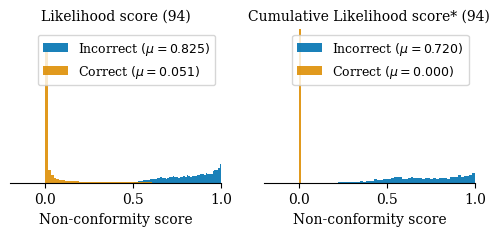

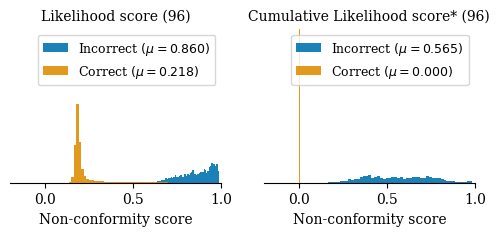

In [21]:
def plot_ncscore_hist(clf_ncscore, misclassification_mask, ax):
    ax.hist(clf_ncscore[misclassification_mask], label=r'Incorrect $(\mu={:.3f})$'.format(clf_ncscore[misclassification_mask].mean()), bins=50, density=True, alpha=0.9, color=palette[0])
    ax.hist(clf_ncscore[~misclassification_mask], label=r'Correct $(\mu={:.3f})$'.format(clf_ncscore[~misclassification_mask].mean()), bins=50, density=True, alpha=0.9, color=palette[1])
    ax.legend()
    ax.set_xlabel('Non-conformity score')
    # ax.set_ylabel('Density')
    ax.set_ylim(0, 50)
    ax.set_xlim(-.2, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.legend()
    return ax

def make_plot(target):
    algo = "analyze_predictive_uncertainty_against_accuracy"
    current_dir = Path().resolve()
    output_dir = current_dir / "results" / algo / f"target{target}"

    clf_logits_ncscore = torch.load(output_dir / "clf_logits_ncscore.pth", map_location=torch.device('cpu'))
    clf_cumul_ncscore = torch.load(output_dir / "clf_cumul_ncscore.pth", map_location=torch.device('cpu'))
    logits = torch.load(output_dir / "logits.pth", map_location=torch.device('cpu'))
    labels = torch.load(output_dir / "labels.pth", map_location=torch.device('cpu'))

    misclassification_mask = logits.argmax(1) != labels
    fig, axes = plt.subplots(1, 2, figsize=(6, 2))
    plot_ncscore_hist(clf_logits_ncscore, misclassification_mask, axes[0])
    axes[0].set_title(f"Likelihood score ({target})")
    plot_ncscore_hist(clf_logits_ncscore - (1-clf_cumul_ncscore), misclassification_mask, axes[1])
    axes[1].set_title(r"Cumulative Likelihood score*" + f" ({target})")
    print("Notice that the cumulative score exclude the correct logits and only consider those greater than the correct logit")

make_plot("94")
make_plot("96")

In [202]:
# Compute efficiency
q = clf_logits_ncscore.type(torch.float32).quantile(0.8)
efficiency = ((1-logits.softmax(axis=1)) < q).sum(axis=1).float(); print(efficiency.mean())

tensor(0.8095)


In [22]:
def get_target_data(target):
    data = {}
    algo = "analyze_predictive_uncertainty_against_accuracy"
    current_dir = Path().resolve()
    output_dir = current_dir / "results" / algo / f"target{target}"

    data['clf_logits_ncscore'] = torch.load(output_dir / "clf_logits_ncscore.pth", map_location=torch.device('cpu'))
    data['clf_cumul_ncscore'] = 1 - torch.load(output_dir / "clf_cumul_ncscore.pth", map_location=torch.device('cpu'))
    data['logits'] = torch.load(output_dir / "logits.pth", map_location=torch.device('cpu'))
    data['labels'] = torch.load(output_dir / "labels.pth", map_location=torch.device('cpu'))
    data['pred'] = data['logits'].argmax(axis=1)
    return data

target94_data = get_target_data('94')
target96_data = get_target_data('96')

t94_correct_mask = target94_data['pred'] == target94_data['labels']
t96_correct_mask = target96_data['pred'] == target96_data['labels']
both_correct_mask = t94_correct_mask & t96_correct_mask
only_t94_correct_mask = t94_correct_mask & ~t96_correct_mask
only_t96_correct_mask = ~t94_correct_mask & t96_correct_mask
neither_correct_mask = ~t94_correct_mask & ~t96_correct_mask


print("=" * 50)
print(f"Accuracy for target 94: {len(target94_data['labels'][t94_correct_mask]) / len(target94_data['labels']) * 100:.2f}%")
print(f"Accuracy for target 96: {len(target96_data['labels'][t96_correct_mask]) / len(target96_data['labels']) * 100:.2f}%")
print("=" * 50)
print(f"Both correct for target 94 and 96: {len(target94_data['labels'][both_correct_mask]) / len(target94_data['labels']) * 100:.2f}%")
print(f"Only correct for target 94: {len(target94_data['labels'][only_t94_correct_mask]) / len(target94_data['labels']) * 100:.2f}%")
print(f"Only correct for target 96: {len(target96_data['labels'][only_t96_correct_mask]) / len(target96_data['labels']) * 100:.2f}%")
print(f"Neither correct: {len(target94_data['labels'][neither_correct_mask]) / len(target94_data['labels']) * 100:.2f}%")
print("=" * 50)


Accuracy for target 94: 93.07%
Accuracy for target 96: 94.61%
Both correct for target 94 and 96: 91.28%
Only correct for target 94: 1.79%
Only correct for target 96: 3.33%
Neither correct: 3.60%


In [23]:
import torchvision
path = Path().absolute() / "cifar10"
dataset = torchvision.datasets.CIFAR10(path, download=False, train=True)

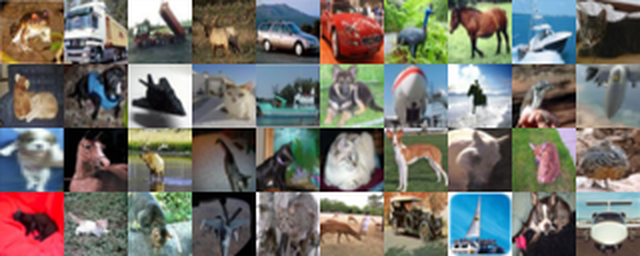

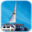

'ship'

In [27]:
from PIL import Image

def concatenate_images_horizontally(images, n_width):
    # Calculate total width and max height
    total_width = sum(img.width for img in images[:n_width])
    n_height = len(images) // n_width
    total_height = sum(img.height for img in images[:n_height])
    
    # Create a new blank image
    new_image = Image.new('RGB', (total_width, total_height))
    
    # Paste images side by side
    x_offset = 0
    y_offset = 0
    for i, img in enumerate(images):
        new_image.paste(img, (x_offset, y_offset))
        x_offset += img.width
        if (i + 1) % n_width == 0:
            x_offset = 0
            y_offset += img.height
    
    return new_image

images = [dataset[i][0] for i in torch.arange(len(dataset))[both_correct_mask][:10]]
images += [dataset[i][0] for i in torch.arange(len(dataset))[only_t94_correct_mask][:10]]
images += [dataset[i][0] for i in torch.arange(len(dataset))[only_t96_correct_mask][:10]]
images += [dataset[i][0] for i in torch.arange(len(dataset))[neither_correct_mask][:10]]
concat_image = concatenate_images_horizontally(images, 10)

original_width, original_height = concat_image.size
new_size = (original_width * 2, original_height * 2)  # Double the size
resized_image = concat_image.resize(new_size, Image.LANCZOS)  # High-quality interpolation

display(resized_image)

img, label = dataset[torch.arange(len(dataset))[neither_correct_mask][7]]
display(img)
dataset.classes[label]


# Experiment 1

In [110]:
import sys
import subprocess

current_dir = Path().absolute()
root_dir = current_dir.parent.parent
sys.path.append(str(root_dir / "src"))
from utils import run_command


P = subprocess.run(["python", "main.py", "algo1-exp", "--identifiers-only"], cwd=current_dir, capture_output=True)
_stderr = P.stderr.decode()
_stdout = P.stdout.decode()
identifiers = eval(_stdout)

In [138]:
import pandas as pd

output_dir = current_dir / "results" / 'algo1'
_data = []
for _id in identifiers:
    file = output_dir / f"{_id}.csv"
    dataset, algo, confname, k, alpha, threshold, seed = _id.split("_")
    df = pd.read_csv(file, index_col=0)
    _data.append({
        "target": dataset.split("-")[-1],
        "algo": algo,
        "confname": confname,
        "k": k,
        "alpha": alpha,
        "threshold": threshold,
        "tta_val_acc": df['tta_val_acc'].iloc[-1],
        "seed": seed,
    })
df = pd.DataFrame(_data)
df = df.astype(dtype={"k": "int32", "alpha": "float32", "threshold": "float32", "seed": "int32", "tta_val_acc": "float32"})
del df['algo'], df['k'], df['seed']

In [139]:
df.groupby(["target", "confname", 'alpha', 'threshold']).mean().sort_values(by="tta_val_acc", ascending=False)

tta_val_acc
target confname   alpha threshold             
96     CLF-Logits 0.20  3.0            0.95502
                  0.10  2.0            0.95444
                  0.15  2.0            0.95442
                  0.05  3.0            0.95432
                  0.10  3.0            0.95416
                  0.20  2.0            0.95412
                  0.05  2.0            0.95400
                  0.15  3.0            0.95378
94     CLF-Logits 0.10  2.0            0.94496
                  0.15  3.0            0.94484
                  0.20  3.0            0.94408
                        2.0            0.94408
                  0.10  3.0            0.94384
                  0.05  2.0            0.94374
                  0.15  2.0            0.94360
                  0.05  3.0            0.94340